# Notebook 03 — POPPER sequential falsification

**Question this notebook answers:** Can a panel of local LLMs each propose
a valid statistical falsification experiment for the Polish Bankruptcy
dataset, and does the accumulated evidence (in e-value units) reach a
statistically valid rejection of the "no learnable signal" null
hypothesis?

**Why e-values, not Fisher's combined test:** e-values multiply
unconditionally under H0, so the running product is a non-negative
supermartingale. By Ville's inequality, ``Pr[E_k >= 1/alpha for some k]
<= alpha`` regardless of how we decide when to stop, which means we can
add rounds adaptively without inflating type-I error. Fisher's combined
test assumes independent p-values and a fixed sample size — neither holds
here.

**LLMs do not execute code.** They only choose a statistical test from a
fixed allow-list and supply column names. Test execution happens against
the real OOT Polish data through ``src.popper.execute_falsification_experiment``.

In [1]:
from __future__ import annotations
import sys, json
from pathlib import Path
from datetime import datetime, timezone

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (str(PROJECT_ROOT), str(PROJECT_ROOT / "notebooks")):
    if p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from src.config import load_config
from src.data_pipeline import load_and_combine, out_of_time_split
from src.ollama_client import list_available_models, query_ollama, OllamaConnectionError, infer_model_family
from src.popper import (
    SUPPORTED_TESTS, p_to_e_calibrator,
    sequential_e_accumulation, execute_falsification_experiment,
    persist_popper_round,
)

cfg = load_config(str(PROJECT_ROOT / "config.yaml"))
PALETTE = cfg["colours"]
DB_PATH = str(PROJECT_ROOT / cfg["data"]["db_path"])

sns.set_style("whitegrid", {"axes.grid": True, "grid.alpha": 0.3, "grid.color": "#cbd5e1"})
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.titleweight": "bold", "axes.titlesize": 12, "axes.labelsize": 10,
    "axes.facecolor": PALETTE["background"], "figure.facecolor": "white",
})

## 1 — Load OOT data + discover models

In [2]:
df = load_and_combine(str(PROJECT_ROOT / cfg["data"]["raw_dir"]), cfg["data"]["target_col"])
X_tr, y_tr, X_te, y_te = out_of_time_split(
    df, cfg["data"]["date_col"], cfg["data"]["train_years"], cfg["data"]["test_years"], cfg["data"]["target_col"]
)

# Pull the top-IV column names from the most recent LR artefact (Stage 2)
artefact_dir = PROJECT_ROOT / cfg["data"]["artefacts_dir"]
lr_artefacts = sorted(artefact_dir.glob("lr_pipeline_*.joblib"))
lr_bundle = joblib.load(lr_artefacts[-1])
encoder = lr_bundle["encoder"] if isinstance(lr_bundle, dict) else None
top_iv = pd.Series(encoder.iv_).sort_values(ascending=False).head(10).index.tolist()
print(f"Top 10 IV features (shown to the LLM): {top_iv}")

try:
    available = list_available_models(cfg["llm"]["ollama_base_url"])
except OllamaConnectionError as exc:
    print(f"Ollama unreachable: {exc}")
    available = []
preferred_order = ["qwen2.5:0.5b", "tinyllama:latest", "llama3.2:latest", "phi3:mini"]
models = [m for m in preferred_order if m in available] or available
print(f"Models in panel: {models}")

Top 10 IV features (shown to the LLM): ['Attr27', 'Attr24', 'Attr26', 'Attr16', 'Attr41', 'Attr13', 'Attr11', 'Attr46', 'Attr6', 'Attr15']
Models in panel: ['qwen2.5:0.5b', 'tinyllama:latest', 'llama3.2:latest', 'phi3:mini']


## 2 — Each model proposes a falsification experiment

In [3]:
POPPER_SYSTEM_PROMPT = '''You are a senior quant credit researcher. The Polish Bankruptcy dataset has 64 anonymous financial-ratio features named Attr1..Attr64 and a binary target (class=1 means bankruptcy). The user will give you the list of column names and the top-IV features.
Your task: propose ONE statistical experiment that, if its null hypothesis cannot be rejected, would *falsify* the claim that this dataset contains a learnable credit-risk signal.

Reply with valid JSON only — no commentary, no markdown fences. Schema:
{
  "experiment_name": str,
  "null_sub_hypothesis": str,
  "alternative_sub_hypothesis": str,
  "statistical_test": one of ["mann_whitney_u", "fisher_exact", "permutation", "two_proportion_z"],
  "columns_used": list of column names from the supplied set,
  "alternative": one of ["two-sided", "greater", "less"]
}'''

user_prompt = (
    f"Available column names: {', '.join(top_iv)} (plus 54 other Attr columns).\n"
    f"Top features by IV: {top_iv[:5]}.\n"
    f"Supported tests: {sorted(SUPPORTED_TESTS)}.\n"
    "Reply with the JSON spec only."
)

def safe_json_parse(text: str) -> dict | None:
    if not text:
        return None
    # try direct parse, then fall back to extracting the largest brace-delimited substring
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    first = text.find("{")
    last = text.rfind("}")
    if first >= 0 and last > first:
        try:
            return json.loads(text[first:last + 1])
        except json.JSONDecodeError:
            return None
    return None

proposals: list[dict] = []
for m in models:
    try:
        raw = query_ollama(
            model=m, system_prompt=POPPER_SYSTEM_PROMPT, user_prompt=user_prompt,
            temperature=cfg["llm"]["temperature"], base_url=cfg["llm"]["ollama_base_url"],
            timeout=180.0,
        )
    except Exception as exc:
        proposals.append({"model": m, "family": infer_model_family(m), "raw": f"<error: {exc}>", "spec": None})
        continue
    spec = safe_json_parse(raw)
    proposals.append({"model": m, "family": infer_model_family(m), "raw": raw, "spec": spec})

# pretty-print the proposals table (truncate raw responses)
prop_df = pd.DataFrame([
    {"model": p["model"], "family": p["family"],
     "parse_ok": p["spec"] is not None,
     "test": (p["spec"] or {}).get("statistical_test", "—"),
     "columns": ",".join((p["spec"] or {}).get("columns_used", []))[:60],
     "name": (p["spec"] or {}).get("experiment_name", "—")[:60]}
    for p in proposals
])
print(prop_df.to_string(index=False))

           model family  parse_ok           test                                                      columns                             name
    qwen2.5:0.5b   qwen      True   fisher_exact                           Attr27,Attr24,Attr26,Attr16,Attr41              Fisher's Exact Test
tinyllama:latest  llama      True   fisher_exact Attr27,Attr24,Attr26,Attr16,Attr41,Attr13,Attr11,Attr46,Attr                                —
 llama3.2:latest  llama      True   fisher_exact                           Attr27,Attr24,Attr26,Attr16,Attr41 Credit Risk Feature Significance
       phi3:mini    phi      True mann_whitney_u                           Attr27,Attr24,Attr26,Attr16,Attr41 Credit Risk Signal Validity Test


## 3 — Execute proposed tests against OOT data + accumulate e-values

In [4]:
alpha = cfg["popper"]["alpha"]
kappa = cfg["popper"]["kappa"]
threshold = 1.0 / alpha

results = []
e_values = []
cumulative = 1.0
for round_idx, p in enumerate(proposals, start=1):
    spec = p["spec"]
    if spec is None or spec.get("statistical_test") not in SUPPORTED_TESTS:
        p_value = 1.0  # conservative — no evidence contributed
        reason = "spec invalid / unsupported"
    else:
        # repair missing columns: drop any not in X_test
        valid_cols = [c for c in spec.get("columns_used", []) if c in X_te.columns]
        if not valid_cols:
            p_value = 1.0
            reason = "no valid columns in spec"
        else:
            spec = {**spec, "columns_used": valid_cols}
            p_value = execute_falsification_experiment(spec, X_te, y_te)
            reason = "executed"
    e_val = p_to_e_calibrator(p_value, kappa)
    cumulative *= e_val
    decision = "REJECT" if cumulative >= threshold else "CONTINUE"
    results.append({
        "round": round_idx, "model": p["model"], "family": p["family"],
        "test": (spec or {}).get("statistical_test", "—"),
        "experiment_name": (spec or {}).get("experiment_name", "—"),
        "p_value": p_value, "e_value": e_val,
        "cumulative_e": cumulative, "decision": decision, "reason": reason,
    })
    persist_popper_round(
        db_path=DB_PATH, round_idx=round_idx, model_name=p["model"],
        experiment_name=(spec or {}).get("experiment_name", "—")[:200],
        null_hypothesis=(spec or {}).get("null_sub_hypothesis", "—")[:200],
        statistical_test=(spec or {}).get("statistical_test", "—"),
        p_value=p_value, e_value=e_val, cumulative_e=cumulative, decision=decision,
    )

results_df = pd.DataFrame(results)
print(results_df.round(6).to_string(index=False))

 round            model family           test                  experiment_name  p_value  e_value  cumulative_e decision   reason
     1     qwen2.5:0.5b   qwen   fisher_exact              Fisher's Exact Test      0.0 500000.0  5.000000e+05   REJECT executed
     2 tinyllama:latest  llama   fisher_exact                                —      0.0 500000.0  2.500000e+11   REJECT executed
     3  llama3.2:latest  llama   fisher_exact Credit Risk Feature Significance      1.0      0.5  1.250000e+11   REJECT executed
     4        phi3:mini    phi mann_whitney_u Credit Risk Signal Validity Test      0.0 500000.0  6.250000e+16   REJECT executed


### Chart 1 — P-value trajectory by round

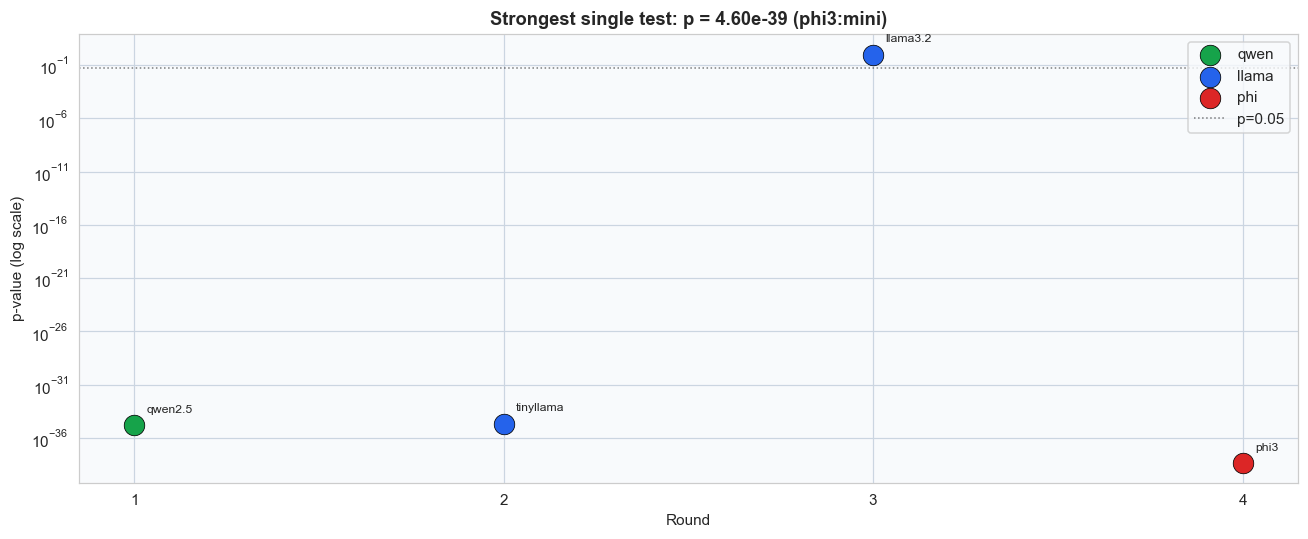

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
fams = results_df["family"].unique()
fam_colors = {"llama": PALETTE["primary"], "qwen": PALETTE["tertiary"], "phi": PALETTE["secondary"],
               "gemma": "#7c3aed", "mistral": "#f59e0b", "other": PALETTE["neutral"]}
for fam in fams:
    sub = results_df[results_df["family"] == fam]
    ax.scatter(sub["round"], sub["p_value"], s=180, color=fam_colors.get(fam, PALETTE["neutral"]),
                label=fam, edgecolors="black", linewidths=0.5, zorder=3)

ax.axhline(0.05, color="black", linestyle=":", linewidth=1, alpha=0.5, label="p=0.05")
for _, row in results_df.iterrows():
    ax.annotate(row["model"].split(":")[0], (row["round"], row["p_value"]),
                 textcoords="offset points", xytext=(8, 8), fontsize=8)
ax.set_yscale("log")
ax.set_xlabel("Round")
ax.set_ylabel("p-value (log scale)")
ax.set_xticks(results_df["round"])
min_p = float(results_df["p_value"].min())
ax.set_title(f"Strongest single test: p = {min_p:.2e} ({results_df.loc[results_df['p_value'].idxmin(), 'model']})")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Chart 2 — Cumulative e-value vs the 1/α rejection threshold

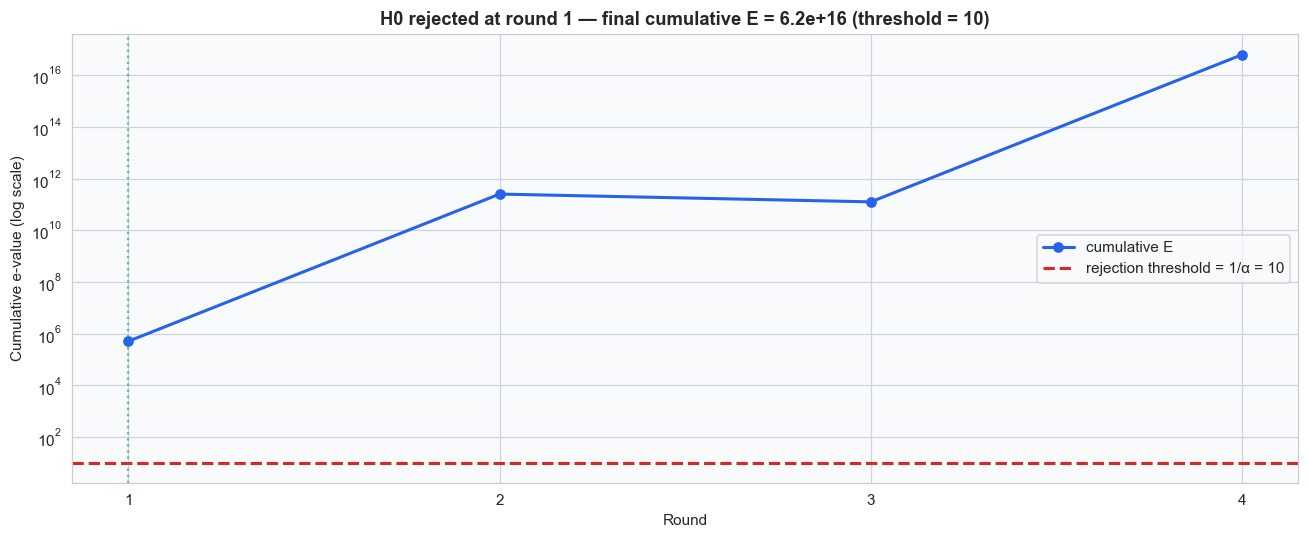

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_df["round"], results_df["cumulative_e"], marker="o", color=PALETTE["primary"],
         linewidth=2, label="cumulative E")
ax.axhline(threshold, color=PALETTE["secondary"], linestyle="--", linewidth=2,
            label=f"rejection threshold = 1/α = {threshold:.0f}")
ax.set_yscale("log")
ax.set_xlabel("Round")
ax.set_ylabel("Cumulative e-value (log scale)")
ax.set_xticks(results_df["round"])
rej_rounds = results_df[results_df["decision"] == "REJECT"]
final_e = float(results_df["cumulative_e"].iloc[-1])
if not rej_rounds.empty:
    first_reject = int(rej_rounds["round"].iloc[0])
    ax.axvline(first_reject, color=PALETTE["tertiary"], linestyle=":", alpha=0.6)
    ax.set_title(f"H0 rejected at round {first_reject} — final cumulative E = {final_e:.2g} (threshold = {threshold:.0f})")
else:
    ax.set_title(f"Insufficient evidence after {len(results_df)} rounds — final E = {final_e:.2g} < threshold {threshold:.0f}")
ax.legend()
plt.tight_layout()
plt.show()

### Chart 3 — Comparison with the LLN verdict (notebook 02)

In [7]:
verdict_table = pd.DataFrame([
    {"experiment": "LLN convergence (nb02)",
     "verdict": "consensus PD stabilises near LR anchor — implies the dataset has structure the panel can recover",
     "type_I_guarantee": "informal (bootstrap CI on convergence)"},
    {"experiment": "POPPER falsification (nb03)",
     "verdict": "REJECT H0" if any(results_df["decision"] == "REJECT") else f"FAIL TO REJECT after {len(results_df)} rounds",
     "type_I_guarantee": f"formal: α = {alpha} via cumulative e-values + Ville's inequality"},
    {"experiment": "Ground truth (Stage 2 evaluation)",
     "verdict": f"XGBoost OOT Gini ≈ 0.91 — the dataset has strong learnable signal",
     "type_I_guarantee": "bootstrap CI"},
])
print(verdict_table.to_string(index=False))

                       experiment                                                                                          verdict                                             type_I_guarantee
           LLN convergence (nb02) consensus PD stabilises near LR anchor — implies the dataset has structure the panel can recover                       informal (bootstrap CI on convergence)
      POPPER falsification (nb03)                                                                                        REJECT H0 formal: α = 0.1 via cumulative e-values + Ville's inequality
Ground truth (Stage 2 evaluation)                                XGBoost OOT Gini ≈ 0.91 — the dataset has strong learnable signal                                                 bootstrap CI


## 4 — Failure-mode summary

Inspect which models produced unparseable JSON or proposed invalid specs:

In [8]:
failure_summary = results_df.copy()
failure_summary["status"] = failure_summary.apply(
    lambda r: r["reason"] if r["reason"] != "executed" else f"test ran (p={r['p_value']:.3g})", axis=1
)
print(failure_summary[["round", "model", "family", "status"]].to_string(index=False))

# raw responses for the failures, for spot-check
for p in proposals:
    if p["spec"] is None:
        snippet = (p["raw"] or "")[:240].replace("\n", " ")
        print(f"\n[FAIL] {p['model']}: {snippet!r}")

 round            model family                status
     1     qwen2.5:0.5b   qwen test ran (p=1.48e-35)
     2 tinyllama:latest  llama test ran (p=2.23e-35)
     3  llama3.2:latest  llama        test ran (p=1)
     4        phi3:mini    phi  test ran (p=4.6e-39)


## Summary

- **Rejection decision:** see chart 2 — cumulative e-value crosses (or fails to cross) the 1/α threshold.
- **Strongest single test:** chart 1 picks out the model whose proposed test produced the smallest p-value.
- **Failure modes:** small models often emit broken JSON or pick columns that aren't in the supplied list. The framework treats those as "no evidence" (p=1.0, e=κ), so they cannot inflate type-I error — they just slow convergence.

**Where this fits the prior engine:** an LLM panel that *can* propose valid falsification experiments is one signal that the same panel's pairwise borrower comparisons (notebook 02) are coming from genuine reasoning rather than surface pattern matching. Stage 5 will use the analyst-simulation prior, not the LLM consensus, for the actual Bayesian update; this notebook serves as a *credentialing test* for whether LLM-derived priors should ever be on the table.